In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterSampler
import gymnasium as gym
from gymnasium.spaces import Discrete, MultiDiscrete
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

class FlattenMultiDiscreteActionWrapper(gym.ActionWrapper):
    def __init__(self, env: gym.Env):
        super().__init__(env)
        self.nvec = env.action_space.nvec
        self.action_space = Discrete(int(np.prod(self.nvec)))

    def action(self, action: int) -> np.ndarray:
        return np.array(np.unravel_index(action, self.nvec), dtype=self.env.action_space.dtype)

def make_eval_env():
    return FlattenMultiDiscreteActionWrapper(
        IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True,
        )
    )

def evaluate_cost(model, n_episodes=5, seed=2026):
    """Evaluates policy and returns true unscaled average episode cost."""
    test_env = make_eval_env()
    costs = []
    for ep in range(n_episodes):
        obs, info = test_env.reset(seed=seed + ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, term, trunc, info = test_env.step(action)
            done = term or trunc
        costs.append(info["costs"]["episode_total"])
    return float(np.mean(costs)), float(np.std(costs))

In [11]:
# For hyper parameter tuning
param_distributions = {
    "learning_rate": [3e-4, 7e-4, 1.5e-3],
    "gamma": [0.95, 0.98, 0.99],
    "batch_size": [64, 128],
    "target_update_interval": [250, 500, 1000],
    "train_freq": [4, 8],
    "gradient_steps": [4, 8],
    "exploration_fraction": [0.3, 0.5],
    "exploration_final_eps": [0.02, 0.05],
    "net_arch": [[256, 256], [512, 256]],
}

N_ITER = 8              # Number of random hyperparameter configurations to sample
TOTAL_TIMESTEPS = 40000 
N_ENVS = 4

param_list = list(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=2026))
param_list

[{'train_freq': 8,
  'target_update_interval': 1000,
  'net_arch': [256, 256],
  'learning_rate': 0.0003,
  'gradient_steps': 8,
  'gamma': 0.95,
  'exploration_fraction': 0.5,
  'exploration_final_eps': 0.02,
  'batch_size': 64},
 {'train_freq': 4,
  'target_update_interval': 1000,
  'net_arch': [512, 256],
  'learning_rate': 0.0003,
  'gradient_steps': 8,
  'gamma': 0.98,
  'exploration_fraction': 0.3,
  'exploration_final_eps': 0.05,
  'batch_size': 128},
 {'train_freq': 4,
  'target_update_interval': 500,
  'net_arch': [256, 256],
  'learning_rate': 0.0003,
  'gradient_steps': 4,
  'gamma': 0.99,
  'exploration_fraction': 0.5,
  'exploration_final_eps': 0.05,
  'batch_size': 64},
 {'train_freq': 4,
  'target_update_interval': 1000,
  'net_arch': [256, 256],
  'learning_rate': 0.0007,
  'gradient_steps': 4,
  'gamma': 0.98,
  'exploration_fraction': 0.3,
  'exploration_final_eps': 0.02,
  'batch_size': 128},
 {'train_freq': 8,
  'target_update_interval': 1000,
  'net_arch': [256, 25

In [12]:
results = []
best_cost = float("inf")
best_model = None
best_params = None

for i, params in enumerate(param_list):
    print(f"\n--- Running Trial {i+1}/{N_ITER} ---")
    print(params)

    vec_env = VecMonitor(DummyVecEnv([make_eval_env for _ in range(N_ENVS)]))
    
    policy_kwargs = dict(net_arch=params["net_arch"])

    model = DQN(
        "MultiInputPolicy",
        vec_env,
        learning_rate=params["learning_rate"],
        gamma=params["gamma"],
        batch_size=params["batch_size"],
        buffer_size=100000,
        learning_starts=1000,
        target_update_interval=params["target_update_interval"],
        train_freq=params["train_freq"],
        gradient_steps=params["gradient_steps"],
        exploration_fraction=params["exploration_fraction"],
        exploration_final_eps=params["exploration_final_eps"],
        policy_kwargs=policy_kwargs,
        seed=2026,
        verbose=0,
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS)

    mean_cost, std_cost = evaluate_cost(model, n_episodes=5, seed=2026)
    print(f"Trial {i+1} Mean Episode Cost: {mean_cost:,.2f} (+/- {std_cost:,.2f})")

    trial_record = {**params, "mean_cost": mean_cost, "std_cost": std_cost}
    results.append(trial_record)

    if mean_cost < best_cost:
        best_cost = mean_cost
        best_model = model
        best_params = params


--- Running Trial 1/8 ---
{'train_freq': 8, 'target_update_interval': 1000, 'net_arch': [256, 256], 'learning_rate': 0.0003, 'gradient_steps': 8, 'gamma': 0.95, 'exploration_fraction': 0.5, 'exploration_final_eps': 0.02, 'batch_size': 64}
Trial 1 Mean Episode Cost: 142,162.50 (+/- 13,980.27)

--- Running Trial 2/8 ---
{'train_freq': 4, 'target_update_interval': 1000, 'net_arch': [512, 256], 'learning_rate': 0.0003, 'gradient_steps': 8, 'gamma': 0.98, 'exploration_fraction': 0.3, 'exploration_final_eps': 0.05, 'batch_size': 128}
Trial 2 Mean Episode Cost: 132,074.50 (+/- 13,391.87)

--- Running Trial 3/8 ---
{'train_freq': 4, 'target_update_interval': 500, 'net_arch': [256, 256], 'learning_rate': 0.0003, 'gradient_steps': 4, 'gamma': 0.99, 'exploration_fraction': 0.5, 'exploration_final_eps': 0.05, 'batch_size': 64}
Trial 3 Mean Episode Cost: 134,046.00 (+/- 9,793.09)

--- Running Trial 4/8 ---
{'train_freq': 4, 'target_update_interval': 1000, 'net_arch': [256, 256], 'learning_rate': 0

In [ ]:
df_results = pd.DataFrame(results).sort_values("mean_cost")
print("\n=== Search Results ===")
print(df_results[["learning_rate", "gamma", "batch_size", "train_freq", "mean_cost", "std_cost"]])

print(f"\nBest Config Achieved Cost: {best_cost:,.2f}")
best_model.save("dqn_industrial_inventory_tuned.zip")


=== Search Results ===
   learning_rate  gamma  batch_size  train_freq  mean_cost      std_cost
7         0.0007   0.99          64           4   111934.5   2535.477470
3         0.0007   0.98         128           4   118570.0  15157.855472
6         0.0007   0.95         128           8   124744.5   8688.963747
5         0.0003   0.98          64           8   131507.5  12802.376537
1         0.0003   0.98         128           4   132074.5  13391.872759
2         0.0003   0.99          64           4   134046.0   9793.094838
0         0.0003   0.95          64           8   142162.5  13980.272530
4         0.0003   0.98          64           8   173509.0  20269.155483

Best Config Achieved Cost: 111,934.50


In [15]:
# eval on fresh env
# manual eval loop for 1 episode, to get the info dict for each step, to get the costs
loaded_model = DQN.load("dqn_industrial_inventory_tuned.zip")
env = make_eval_env()
records = []
observation, info = env.reset(seed=2026)
while True:
    # now action is coming single number, not list [int, int, int] as before, because of the wrapper
    action_scalar, _ = loaded_model.predict(observation, deterministic=True)  # MultiDiscrete indices directly
    observation, reward, terminated, truncated, info = env.step(action_scalar)
    records.append({
        "action": env.action(action_scalar),  # convert back to MultiDiscrete indices vector for logging [int, int, int]
        "reward": reward,
        "truncated": truncated,
        "info": info,
        'day': info['day'],
        **info['costs']
    })
    if terminated or truncated:
        break

df = pd.DataFrame(records)
df

,action,reward,truncated,info,day,holding,stockout,ordering,discarding,daily_total,episode_total
0,"[6, 4, 3]",-28.625,False,"{'day': 0, 'demand': [34, 21, 21], 'fulfilled_...",0,2462.5,0.0,400.0,0.0,2862.5,2862.5
1,"[4, 0, 1]",-20.500,False,"{'day': 1, 'demand': [29, 23, 27], 'fulfilled_...",1,1850.0,0.0,200.0,0.0,2050.0,4912.5
2,"[8, 1, 3]",-19.500,False,"{'day': 2, 'demand': [27, 33, 28], 'fulfilled_...",2,1550.0,0.0,400.0,0.0,1950.0,6862.5
3,"[0, 2, 2]",-17.125,False,"{'day': 3, 'demand': [42, 25, 25], 'fulfilled_...",3,1392.5,0.0,320.0,0.0,1712.5,8575.0
4,"[5, 4, 10]",-15.950,False,"{'day': 4, 'demand': [26, 28, 29], 'fulfilled_...",4,1195.0,0.0,400.0,0.0,1595.0,10170.0
5,"[5, 4, 2]",-26.775,False,"{'day': 5, 'demand': [22, 23, 27], 'fulfilled_...",5,2277.5,0.0,400.0,0.0,2677.5,12847.5
6,"[0, 2, 0]",-22.200,False,"{'day': 6, 'demand': [28, 25, 27], 'fulfilled_...",6,2020.0,0.0,200.0,0.0,2220.0,15067.5
7,"[0, 2, 0]",-26.350,False,"{'day': 7, 'demand': [34, 21, 24], 'fulfilled_...",7,2435.0,0.0,200.0,0.0,2635.0,17702.5
8,"[3, 0, 0]",-24.650,False,"{'day': 8, 'demand': [28, 24, 28], 'fulfilled_...",8,2385.0,0.0,80.0,0.0,2465.0,20167.5
9,"[0, 6, 2]",-19.800,False,"{'day': 9, 'demand': [44, 24, 30], 'fulfilled_...",9,1660.0,0.0,320.0,0.0,1980.0,22147.5


<Axes: >

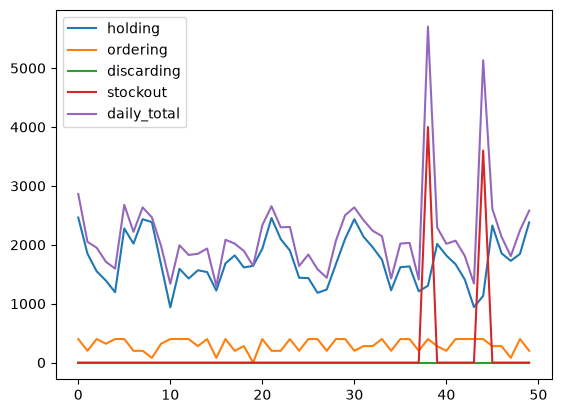

In [16]:
df[['holding', 'ordering', 'discarding', 'stockout', 'daily_total']].plot()